=== CPU-Optimized BioBERT Training ===
Loading data...
Sampled 20.0% of data for faster development
Training samples: 537207
Validation samples: 42980
Training label distribution: 1    268956
0    268251
Name: count, dtype: int64
Validation label distribution: 0    38369
1     4611
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Evaluating: 100%|██████████| 10745/10745 [01:53<00:00, 94.88it/s]


Train Loss: 0.4204, Train Acc: 0.7465
Val Loss: 0.4923, Val Acc: 0.6050
Val Precision: 0.2092, Val Recall: 0.9646, Val F1: 0.3439
Model saved to best_biobert_upcoding_model.pth
New best model saved with validation accuracy: 0.6050

Epoch 2/2
--------------------------------------------------


Evaluating: 100%|██████████| 10745/10745 [01:52<00:00, 95.74it/s]


Train Loss: 0.3884, Train Acc: 0.7594
Val Loss: 0.3860, Val Acc: 0.6051
Val Precision: 0.2092, Val Recall: 0.9646, Val F1: 0.3439
Model saved to best_biobert_upcoding_model.pth
New best model saved with validation accuracy: 0.6051


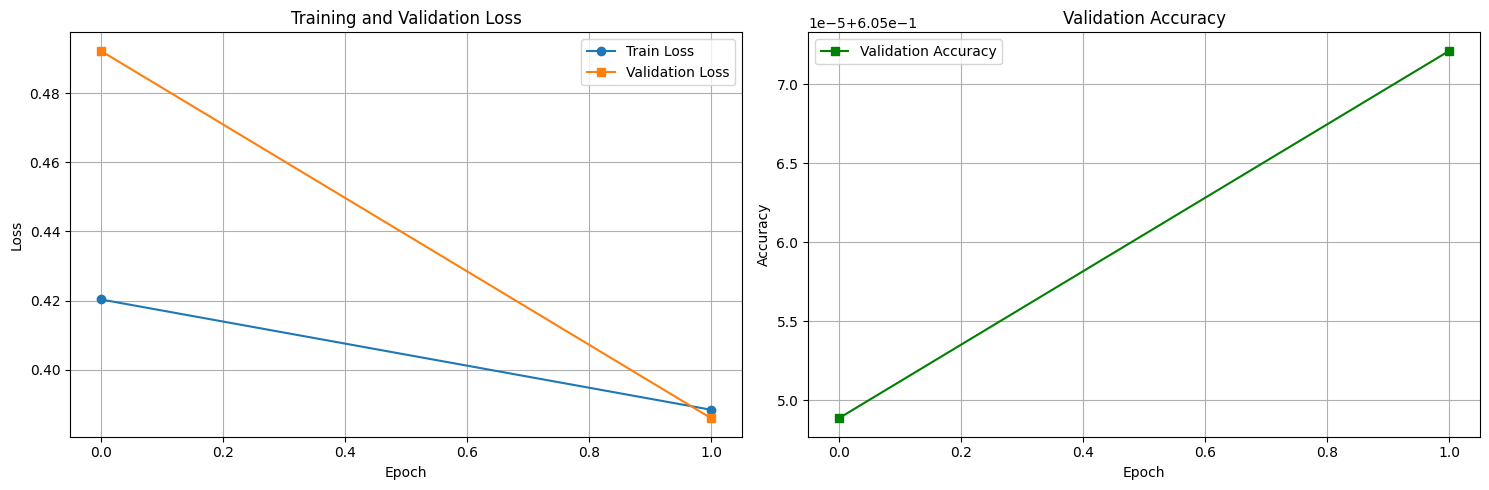


Final evaluation on validation set:


Evaluating: 100%|██████████| 10745/10745 [01:51<00:00, 95.97it/s]


Validation Accuracy: 0.6051
Validation Precision: 0.2092
Validation Recall: 0.9646
Validation F1-Score: 0.3439
Validation AUC-ROC: 0.8774


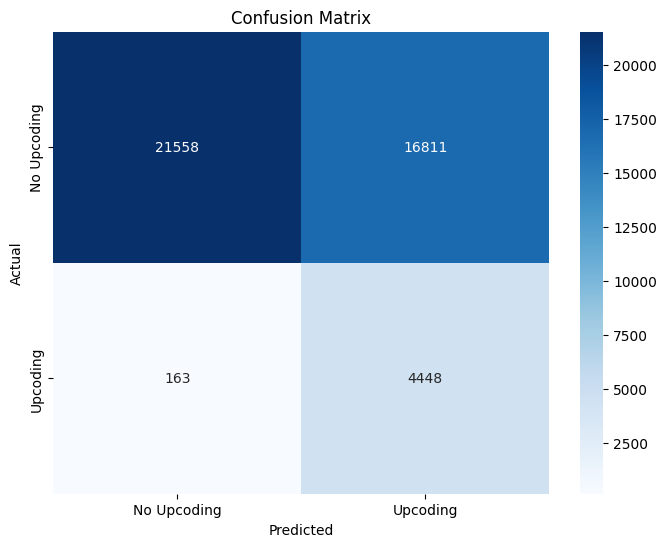


Example prediction:


Predicting: 100%|██████████| 1/1 [00:00<00:00, 116.05it/s]


Sample 1:
Text: Patient diagnosed with acute myocardial infarction with multiple complications requiring extensive treatment
Prediction: No Upcoding
Upcoding Probability: 0.0002

Sample 2:
Text: Routine checkup shows normal vital signs and no complications
Prediction: No Upcoding
Upcoding Probability: 0.0064


<function __main__.main()>

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModel, 
    get_linear_schedule_with_warmup
)
try:
    from transformers import AdamW
except ImportError:
    from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

class MedicalRecordsDataset(Dataset):
    """Custom Dataset for medical records classification"""
    
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize and encode
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

class BioBERTClassifier(nn.Module):
    """BioBERT-based binary classifier for upcoding detection"""
    
    def __init__(self, model_name='nlpie/bio-distilbert-uncased', num_classes=2, dropout_rate=0.2):
        super(BioBERTClassifier, self).__init__()
        
        self.biobert = AutoModel.from_pretrained(model_name)
        
        # Freeze early layers for faster training (optional)
        # Uncomment the following lines to freeze first 6 layers
        # for param in self.biobert.encoder.layer[:6].parameters():
        #     param.requires_grad = False
        
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.biobert.config.hidden_size, num_classes)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.biobert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Correctly get the [CLS] token's hidden state
        # It's the first token (index 0) of the last_hidden_state
        cls_token_hidden_state = outputs.last_hidden_state[:, 0, :]
        
        # Apply dropout and classifier
        pooled_output = self.dropout(cls_token_hidden_state)
        logits = self.classifier(pooled_output)
        
        return logits

class UpcodingDetector:
    """Main class for training and evaluating the upcoding detection model"""
    
    def __init__(self, model_name='nlpie/bio-distilbert-uncased', max_length=128, learning_rate=5e-5):
        self.model_name = model_name
        self.max_length = max_length
        self.learning_rate = learning_rate
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # CPU-specific optimizations
        if self.device.type == 'cpu':
            print("⚠️  Running on CPU - Training will be significantly slower")
            print("💡 Recommendation: Use SAMPLE_FRACTION=0.1 for faster training")
            # Set number of threads for CPU optimization
            torch.set_num_threads(4)  # Adjust based on your CPU cores
        
        # Initialize tokenizer and model
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = BioBERTClassifier(model_name)
        self.model.to(self.device)
        
        print(f"Using device: {self.device}")
        print(f"Model loaded: {model_name}")
        
        # Memory usage estimation for CPU
        if self.device.type == 'cpu':
            model_params = sum(p.numel() for p in self.model.parameters())
            estimated_memory = (model_params * 4) / (1024**3)  # Rough estimate in GB
            print(f"Estimated model memory usage: ~{estimated_memory:.1f}GB")
    
    def create_data_loaders(self, train_texts, train_labels, val_texts, val_labels, batch_size=16):
        """Create DataLoaders for training and validation"""
        
        train_dataset = MedicalRecordsDataset(
            texts=train_texts,
            labels=train_labels,
            tokenizer=self.tokenizer,
            max_length=self.max_length
        )
        
        val_dataset = MedicalRecordsDataset(
            texts=val_texts,
            labels=val_labels,
            tokenizer=self.tokenizer,
            max_length=self.max_length
        )
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        return train_loader, val_loader
    
    def train(self, train_loader, val_loader, epochs=3, warmup_steps=300):
        """Train the model with optimizations for faster runtime"""
        
        # Setup optimizer and scheduler
        optimizer = AdamW(self.model.parameters(), lr=self.learning_rate, weight_decay=0.01)
        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Loss function
        criterion = nn.CrossEntropyLoss()
        
        # Training history
        train_losses = []
        val_losses = []
        val_accuracies = []
        
        best_val_accuracy = 0
        patience = 2  # Early stopping patience
        patience_counter = 0
        
        # Remove mixed precision training for CPU
        scaler = None
        
        for epoch in range(epochs):
            print(f'\nEpoch {epoch + 1}/{epochs}')
            print('-' * 50)
            
            # Training phase
            self.model.train()
            train_loss = 0
            train_correct = 0
            train_total = 0
            
            for batch in tqdm(train_loader, desc="Training"):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                optimizer.zero_grad()
                
                # Standard training (no mixed precision on CPU)
                logits = self.model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                
                train_loss += loss.item()
                _, predicted = torch.max(logits.data, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()
            
            avg_train_loss = train_loss / len(train_loader)
            train_accuracy = train_correct / train_total
            
            # Validation phase (less frequent for speed)
            if epoch % 1 == 0:  # Validate every epoch, change to 2 for every 2nd epoch
                val_loss, val_accuracy, val_metrics = self.evaluate(val_loader, criterion)
                
                # Store metrics
                train_losses.append(avg_train_loss)
                val_losses.append(val_loss)
                val_accuracies.append(val_accuracy)
                
                print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}')
                print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
                print(f'Val Precision: {val_metrics["precision"]:.4f}, Val Recall: {val_metrics["recall"]:.4f}, Val F1: {val_metrics["f1"]:.4f}')
                
                # Early stopping and model saving
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy
                    self.save_model('best_biobert_upcoding_model.pth')
                    print(f'New best model saved with validation accuracy: {val_accuracy:.4f}')
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f'Early stopping after {epoch + 1} epochs')
                        break
        
        return {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies
        }
    
    def evaluate(self, data_loader, criterion=None):
        """Evaluate the model"""
        
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []
        all_probabilities = []
        
        if criterion is None:
            criterion = nn.CrossEntropyLoss()
        
        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Evaluating"):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                logits = self.model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                total_loss += loss.item()
                
                # Get predictions and probabilities
                probabilities = torch.softmax(logits, dim=1)
                _, predicted = torch.max(logits, 1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probabilities.extend(probabilities[:, 1].cpu().numpy())  # Probability of class 1 (upcoding)
        
        avg_loss = total_loss / len(data_loader)
        accuracy = accuracy_score(all_labels, all_predictions)
        
        # Calculate detailed metrics
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_predictions, average='binary'
        )
        
        try:
            auc_roc = roc_auc_score(all_labels, all_probabilities)
        except ValueError:
            auc_roc = 0.0  # Handle case where only one class is present
        
        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc_roc': auc_roc,
            'predictions': all_predictions,
            'labels': all_labels,
            'probabilities': all_probabilities
        }
        
        return avg_loss, accuracy, metrics
    
    def predict(self, texts, batch_size=16):
        """Make predictions on new texts"""
        
        # Create dataset and dataloader
        dummy_labels = [0] * len(texts)  # Dummy labels for consistency
        dataset = MedicalRecordsDataset(
            texts=texts,
            labels=dummy_labels,
            tokenizer=self.tokenizer,
            max_length=self.max_length
        )
        data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        
        self.model.eval()
        predictions = []
        probabilities = []
        
        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Predicting"):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                
                logits = self.model(input_ids, attention_mask)
                probs = torch.softmax(logits, dim=1)
                _, predicted = torch.max(logits, 1)
                
                predictions.extend(predicted.cpu().numpy())
                probabilities.extend(probs[:, 1].cpu().numpy())  # Probability of upcoding
        
        return predictions, probabilities
    
    def save_model(self, path):
        """Save the trained model"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'tokenizer': self.tokenizer,
            'model_name': self.model_name,
            'max_length': self.max_length
        }, path)
        print(f"Model saved to {path}")
    
    def load_model(self, path):
        """Load a trained model"""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Model loaded from {path}")
    
    def plot_training_history(self, history):
        """Plot training metrics"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss plot
        axes[0].plot(history['train_losses'], label='Train Loss', marker='o')
        axes[0].plot(history['val_losses'], label='Validation Loss', marker='s')
        axes[0].set_title('Training and Validation Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)
        
        # Accuracy plot
        axes[1].plot(history['val_accuracies'], label='Validation Accuracy', marker='s', color='green')
        axes[1].set_title('Validation Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.savefig(f'training_history_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png')
        plt.show()
    
    def plot_confusion_matrix(self, labels, predictions, class_names=['No Upcoding', 'Upcoding']):
        """Plot confusion matrix"""
        cm = confusion_matrix(labels, predictions)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.savefig(f'confusion_matrix_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png')
        plt.show()

def load_data(train_path, val_path, text_column='text', label_column='label', sample_fraction=None):
    """
    Load training and validation data from CSV files with optional sampling for faster development
    Expected format: CSV with columns for text and binary labels (0/1)
    """
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    
    # Optional: Sample data for faster development/testing
    if sample_fraction and sample_fraction < 1.0:
        train_df = train_df.sample(frac=sample_fraction, random_state=42)
        val_df = val_df.sample(frac=sample_fraction, random_state=42)
        print(f"Sampled {sample_fraction*100}% of data for faster development")
    
    train_texts = train_df[text_column].tolist()
    train_labels = train_df[label_column].tolist()
    val_texts = val_df[text_column].tolist()
    val_labels = val_df[label_column].tolist()
    
    print(f"Training samples: {len(train_texts)}")
    print(f"Validation samples: {len(val_texts)}")
    print(f"Training label distribution: {pd.Series(train_labels).value_counts()}")
    print(f"Validation label distribution: {pd.Series(val_labels).value_counts()}")
    
    return train_texts, train_labels, val_texts, val_labels

def estimate_training_time(num_samples, batch_size, epochs, device_type='cpu'):
    """
    Estimate training time based on system specifications
    """
    if device_type == 'cpu':
        # CPU processing time estimates (very rough)
        seconds_per_sample = 0.5  # BioBERT on CPU is quite slow
        batches_per_epoch = num_samples // batch_size
        total_batches = batches_per_epoch * epochs
        estimated_seconds = total_batches * batch_size * seconds_per_sample
        
        hours = estimated_seconds // 3600
        minutes = (estimated_seconds % 3600) // 60
        
        print(f"\n⏱️  Estimated CPU Training Time:")
        print(f"   - Total samples: {num_samples}")
        print(f"   - Batches per epoch: {batches_per_epoch}")
        print(f"   - Estimated time: ~{hours:.0f}h {minutes:.0f}m")
        
        if hours > 10:
            print(f"   ⚠️  WARNING: Training will take {hours:.0f}+ hours on CPU!")
            print(f"   💡 Consider using SAMPLE_FRACTION=0.1 to reduce to ~{hours/10:.1f}h")
    
        return estimated_seconds
    """Main training pipeline"""
    
    # CPU-Optimized Configuration
    MODEL_NAME = 'nlpie/bio-distilbert-uncased'
    MAX_LENGTH = 128      # Reduced for CPU efficiency
    BATCH_SIZE = 4        # Small batch size for CPU/RAM constraints
    LEARNING_RATE = 5e-5  # Higher LR for faster convergence on CPU
    EPOCHS = 2            # Minimal epochs for CPU training
    WARMUP_STEPS = 100    # Fewer warmup steps
    SAMPLE_FRACTION = 0.2 # STRONGLY RECOMMENDED: Use 10% of data for CPU training
    
    # Load your data - modify these paths according to your data structure
    TRAIN_DATA_PATH = '/kaggle/input/claims-training/train_data.csv'  # Update with your actual path
    VAL_DATA_PATH = '/kaggle/input/claims-training/val_data.csv'      # Update with your actual path
    
def main():
    """Main training pipeline"""
    
    # CPU-Optimized Configuration
    MODEL_NAME = 'nlpie/bio-distilbert-uncased'
    MAX_LENGTH = 128      # Reduced for CPU efficiency
    BATCH_SIZE = 4        # Small batch size for CPU/RAM constraints
    LEARNING_RATE = 5e-5  # Higher LR for faster convergence on CPU
    EPOCHS = 2            # Minimal epochs for CPU training
    WARMUP_STEPS = 100    # Fewer warmup steps
    SAMPLE_FRACTION = 0.2 # STRONGLY RECOMMENDED: Use 10% of data for CPU training
    
    # Load your data - modify these paths according to your data structure
    TRAIN_DATA_PATH = '/kaggle/input/claims-training/train_data.csv'  # Update with your actual path
    VAL_DATA_PATH = '/kaggle/input/claims-training/val_data.csv'      # Update with your actual path
    
    print("=== CPU-Optimized BioBERT Training ===")
    print("Loading data...")
    try:
        train_texts, train_labels, val_texts, val_labels = load_data(
            TRAIN_DATA_PATH, VAL_DATA_PATH, sample_fraction=SAMPLE_FRACTION
        )
        
        # Estimate training time
        device_type = 'cpu' if not torch.cuda.is_available() else 'gpu'
        estimate_training_time(len(train_texts), BATCH_SIZE, EPOCHS, device_type)
        
    except FileNotFoundError:
        print("Data files not found. Please update the paths or create sample data.")
        # Create sample data for demonstration
        print("Creating sample data for demonstration...")
        train_texts = ["Patient presents with chest pain and shortness of breath"] * 100
        train_labels = [0] * 50 + [1] * 50  # Balanced sample
        val_texts = ["Patient shows symptoms of cardiac distress"] * 40
        val_labels = [0] * 20 + [1] * 20
    except FileNotFoundError:
        print("Data files not found. Please update the paths or create sample data.")
        # Create sample data for demonstration
        print("Creating sample data for demonstration...")
        train_texts = ["Patient presents with chest pain and shortness of breath"] * 100
        train_labels = [0] * 50 + [1] * 50  # Balanced sample
        val_texts = ["Patient shows symptoms of cardiac distress"] * 40
        val_labels = [0] * 20 + [1] * 20
    
    # Initialize detector
    detector = UpcodingDetector(
        model_name=MODEL_NAME,
        max_length=MAX_LENGTH,
        learning_rate=LEARNING_RATE
    )
    
    # Create data loaders
    print("Creating data loaders...")
    train_loader, val_loader = detector.create_data_loaders(
        train_texts, train_labels, val_texts, val_labels, batch_size=BATCH_SIZE
    )
    
    # Train model
    print("Starting training...")
    history = detector.train(
        train_loader, val_loader, epochs=EPOCHS, warmup_steps=WARMUP_STEPS
    )
    
    # Plot training history
    detector.plot_training_history(history)
    
    # Final evaluation
    print("\nFinal evaluation on validation set:")
    val_loss, val_accuracy, val_metrics = detector.evaluate(val_loader)
    
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Precision: {val_metrics['precision']:.4f}")
    print(f"Validation Recall: {val_metrics['recall']:.4f}")
    print(f"Validation F1-Score: {val_metrics['f1']:.4f}")
    print(f"Validation AUC-ROC: {val_metrics['auc_roc']:.4f}")
    
    # Plot confusion matrix
    detector.plot_confusion_matrix(val_metrics['labels'], val_metrics['predictions'])
    
    # Example prediction on new text
    print("\nExample prediction:")
    sample_texts = [
        "Patient diagnosed with acute myocardial infarction with multiple complications requiring extensive treatment",
        "Routine checkup shows normal vital signs and no complications"
    ]
    
    predictions, probabilities = detector.predict(sample_texts)
    
    for i, (text, pred, prob) in enumerate(zip(sample_texts, predictions, probabilities)):
        print(f"\nSample {i+1}:")
        print(f"Text: {text}")
        print(f"Prediction: {'Upcoding' if pred == 1 else 'No Upcoding'}")
        print(f"Upcoding Probability: {prob:.4f}")

if __name__ == "__main__":
    main()

main